In [1]:
%cd ..

/home/suetin/Projects/VSCode/UltrasoundCardiacReconstruction/HeartReconstruction


/home/suetin/Projects/VSCode/UltrasoundCardiacReconstruction/.venv/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import cv2, os
from tqdm import tqdm
from time import time
import json
import torch
import SimpleITK as sitk
from natsort import natsorted

import warnings
warnings.filterwarnings('ignore')

In [3]:
from src.scripts.models.U2Net import U2Net 
from torch.utils.data import TensorDataset, DataLoader, Dataset
import torchvision.transforms.v2 as transforms
from src.scripts.DataLoaders import ImgForPlot

In [4]:
import pickle
import torch.nn as nn
from src.scripts.losses import IoULoss, DiceBCELoss, DiceLoss

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"

image_size = (256, 256)

batch_size = 8
valid_batch_size = 2
epochs = 50

workers = 4

In [6]:
# Check available GPU memory and total GPU memory 
total_free_gpu_memory, total_gpu_memory = torch.cuda.mem_get_info()
print(f"Total free GPU memory: {round(total_free_gpu_memory * 1e-9, 3)} GB")
print(f"Total GPU memory: {round(total_gpu_memory * 1e-9, 3)} GB")

Total free GPU memory: 6.93 GB
Total GPU memory: 8.358 GB


In [7]:
class MyDataset(Dataset):
    def __init__(self, image_paths, mask_paths, img_shape=(256, 256), transform=None):
        """ """
        assert len(image_paths) == len(mask_paths)
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.img_shape = img_shape
        self.transform = transform
        
    def __getitem__(self, index):
        img_path = self.image_paths[index]
        msk_path = self.mask_paths[index]
        image = self.load_image(img_path)
        mask = self.get_mask(msk_path)

        # image = np.transpose(image, (2, 0, 1)).astype(np.float32)
        # mask = np.transpose(mask, (2, 0, 1)).astype(np.float32)
        
        if self.transform is not None:
            transformed = self.transform(image=image, mask=mask)
            image = transformed["image"]
            mask = transformed["mask"]
        
        if mask.shape[-1] == 4:
            mask.permute((2, 0, 1))
        
        return image, mask
    
    def __len__(self):
        return len(self.image_paths)
    
    def load_image(self, path):
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = img / 255
        img = img.astype(np.float32)

        return img

    def get_mask(self, path):

        # Open .txt file
        try:
            txt = np.loadtxt(path)
        except:
            with open(path, 'r') as file:
                txt = file.readlines()
        cls_dict = self.prepare_txt(txt)

        masks = []
        for i in range(4):  # Because we have 4 classes
            mask = np.zeros((self.img_shape + (1, )))
            # Get coordinates for current class
            try:
                points = np.array([[[xi, yi]] for xi, yi in cls_dict[i+1]]).astype(np.int32)
                mask = cv2.fillPoly(mask, [points], color=[255, 255, 255])
                mask = mask / 255   # Scale
            except:
                mask = np.zeros((self.img_shape + (1, )))

            masks.append(mask.astype(np.float32))

        return np.concat(masks, axis=-1)

    def prepare_txt(self, txt):
        """ Convert raw txt file to dict with classes: points """
        xy_dict = {}
        for string in txt:
            if isinstance(string, str):
                string = string.split(" ")
            cls = int(string[0])
            string = string[1:]  # Cut class
            # print(len(string))
            xy = []
            # Transform to (x, y) format
            for i in range(0, len(string), 2):
                x, y = string[i], string[i+1]
                if isinstance(x, str):
                    x, y = float(x), float(y)
                if x < 1.0001:
                    x, y = int(x * self.img_shape[0]), int(y * self.img_shape[1])
                xy.append((x, y))
            # Save
            xy_dict[cls] = np.array(xy)

        return xy_dict

In [8]:
def get_paths(main_path):
    img_paths = [os.path.join(main_path, "images", img_name) for img_name in os.listdir(os.path.join(main_path, 'images'))]
    msk_paths = [os.path.join(main_path, "masks", img_name) for img_name in os.listdir(os.path.join(main_path, 'masks'))]
    img_paths = natsorted(img_paths)
    msk_paths = natsorted(msk_paths)

    return img_paths, msk_paths


train_path = 'data/train/echo/training'
test_path = 'data/train/echo/testing'

train_img_paths, train_msk_paths = get_paths(train_path)
test_img_paths, test_msk_paths = get_paths(test_path)

train_img_paths[:5], train_msk_paths[:5], len(train_img_paths)

(['data/train/echo/training/images/0b059a9395484d67fd64586c48dd95d7.jpg',
  'data/train/echo/training/images/0c1d16cd3fda6c28d9539b4ca61540ab.jpg',
  'data/train/echo/training/images/0e180dc6bab12407bcbfb5a066ebe8a5.jpg',
  'data/train/echo/training/images/1d043d68013b0a066f0a55c2e63cb5a8.jpg',
  'data/train/echo/training/images/3de63a4b97ade92a835ca0e6dfb019eb.jpg'],
 ['data/train/echo/training/masks/0b059a9395484d67fd64586c48dd95d7.txt',
  'data/train/echo/training/masks/0c1d16cd3fda6c28d9539b4ca61540ab.txt',
  'data/train/echo/training/masks/0e180dc6bab12407bcbfb5a066ebe8a5.txt',
  'data/train/echo/training/masks/1d043d68013b0a066f0a55c2e63cb5a8.txt',
  'data/train/echo/training/masks/3de63a4b97ade92a835ca0e6dfb019eb.txt'],
 235)

In [9]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

In [10]:
# train_transform = A.Compose([
#     A.Resize(*image_size),
#     # A.ElasticTransform(p=1, alpha=120, sigma=120 * 0.05, alpha_affine=120 * 0.03),
#     # A.GridDistortion(p=0.15),
#     # A.RGBShift(p=1),
#     # A.Blur(p=0.15),
#     # A.GaussNoise(p=1),
#     # A.ElasticTransform(p=0.15),
#     # A.RandomBrightnessContrast(p=0.15),
#     # A.RandomGamma(p=0.15),
#     # A.CLAHE(p=0.15),
#     # A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
#     ToTensorV2(),
# ], is_check_shapes=False)

# test_transform = A.Compose([
#     A.Resize(*image_size), 
#     # A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)), 
#     ToTensorV2()
# ], is_check_shapes=False)

In [11]:
# Write transform for image
train_transform = transforms.Compose([
    # Turn the image into a torch.Tensor
    transforms.ToTensor(), # this also converts all pixel values from 0 to 255 to be between 0.0 and 1.0 
    transforms.Resize(size=image_size),
])

In [12]:
# train_img_paths = ['data/train/echo/training/images/6226674fda6dc2c06ee1a27b18bad946.jpg',
#                    'data/train/echo/training/images/74b7fbf804f5a7ff757e12f1654c4c25.jpg']
# train_msk_paths = ['data/train/echo/training/masks/6226674fda6dc2c06ee1a27b18bad946.txt',
#                    'data/train/echo/training/masks/74b7fbf804f5a7ff757e12f1654c4c25.txt']

In [13]:
# 
train_dataset = MyDataset(train_img_paths, train_msk_paths, transform=train_transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

test_dataset = MyDataset(test_img_paths, test_msk_paths, transform=train_transform)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

im, m = next(iter(train_dataset))
fig = plt.figure(figsize=(20,20))

plt.subplot(121)
plt.imshow(ImgForPlot(im));
plt.subplot(122)
plt.imshow(ImgForPlot(m).sum(axis=-1), 'gray');
# plt.imshow(m.sum(axis=-1), 'gray');

TypeError: Compose.forward() got an unexpected keyword argument 'image'

In [ ]:
m.shape, im.shape, im.max(), m.max()

(torch.Size([256, 256, 4]), torch.Size([3, 256, 256]), tensor(1.), tensor(1.))

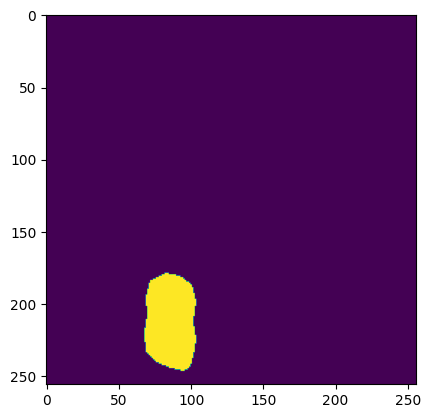

In [ ]:
plt.imshow(m[:, :, 3].cpu().detach().numpy());

## 2. Init Model

In [ ]:
model_saved_dir = "models/U2Net"
if os.path.exists(model_saved_dir) == False:
    os.mkdir(model_saved_dir)
model_name = 'u2net-all'
# loss_path = f"{model_saved_dir}/{model_name}_loss.txt"
model_path = f"{model_saved_dir}/{model_name}.pt"
best_model_path = f"{model_saved_dir}/{model_name}_best.pt"

# with open(loss_path, 'rb') as f:
#   losses = pickle.load(f)

model = U2Net(num_classes=4).to(device)
# Continue lerning
# model.load_state_dict(torch.load(model_path))

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
MAE = nn.L1Loss(reduction='mean')   # Validation
# IoU_loss = IoULoss()
DICE =  DiceLoss()
DBCE = DiceBCELoss()

In [ ]:
LR_START = 0.002
T_alpha = 10   # Time constant, чем меньше тем быстрее
LOW = 0.0001 # 0.0002

def update_lr(epoch, T):
    # Decrease lr every T epochs
    new_lr = (LR_START-LOW) * np.exp(-epoch/T_alpha) + LOW  # lr * math.pow(0.5, epoch // T)
    print('Learning Rate: %.6f' % new_lr)
    for param_group in optimizer.param_groups:
        param_group['lr'] = new_lr

In [ ]:
n_print = 100

start_epoch = 0

if start_epoch == 0:
  losses = {'train': [], 'valid': []}
  best_loss = float("inf")
else:
  best_loss = min(losses['valid'])


for ep in range(start_epoch, epochs):
    update_lr(ep, 4)
    step, loss_sum = 0, 0.
    timestamp = time()
    # Train Model
    model.train()
    for batch_idx, (input, target) in enumerate(train_loader):
        input = input.to(device)
        target = target.to(device)
        step += 1
        
        out = model(input)
        # each_loss = [BCE(o.unsqueeze(1), target) for o in out]
        # print(out.max())
        each_loss = [ DBCE(o, target) for o in out ]   # DBCE
        loss = sum(each_loss)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Append Loss
        losses['train'].append(loss.item())
        loss_sum += loss.item()

        if (batch_idx+1) % n_print == 0 or batch_idx == (len(train_loader)-1):
            print('[%2d/%2d][%4d/%4d] Train: %.4f (%ds)' % (ep+1, epochs, batch_idx+1, len(train_loader), loss_sum/step, time() - timestamp))
            step, loss_sum = 0, 0.
            timestamp = time()
      
    # Evaluate Model
    model.eval()
    step, loss_sum = 0, 0.
    timestamp = time()
    with torch.no_grad():
        for input, target in tqdm(test_loader):
            out = model(input.to(device))[-1]
            if out.ndim == 3:
                out = out.unsqueeze(1)
            
            loss_sum += DICE(out, target.to(device)).item() * input.size(0)  # MAE(out, target.to(device)).item() * input.size(0)
            step += input.size(0)
      
        val_loss = loss_sum / step
        losses['valid'].append(val_loss)
        if val_loss < best_loss:
            best_loss = val_loss
            torch.save(model.state_dict(), best_model_path)
            print("Saved model completely!")

    print('[%2d/%2d] Valid: %.4f (Best: %.4f) (%ds)' % (ep+1, epochs, val_loss, best_loss, time() - timestamp))

    # torch.save(model.state_dict(), model_path)
    # with open(loss_path, 'wb') as f:
    #     pickle.dump(losses, f)
    

Learning Rate: 0.002000
[ 1/50][  30/  30] Train: 8.5311 (9s)


100%|██████████| 4/4 [00:00<00:00,  8.77it/s]


Saved model completely!
[ 1/50] Valid: 0.9415 (Best: 0.9415) (0s)
Learning Rate: 0.001819
[ 2/50][  30/  30] Train: 7.5515 (9s)


100%|██████████| 4/4 [00:00<00:00,  8.96it/s]


[ 2/50] Valid: 0.9845 (Best: 0.9415) (0s)
Learning Rate: 0.001656
[ 3/50][  30/  30] Train: 7.2806 (9s)


100%|██████████| 4/4 [00:00<00:00,  8.83it/s]


Saved model completely!
[ 3/50] Valid: 0.9157 (Best: 0.9157) (0s)
Learning Rate: 0.001508


KeyboardInterrupt: 

In [ ]:
from notebooks.utils import prepare_input, prepare_output

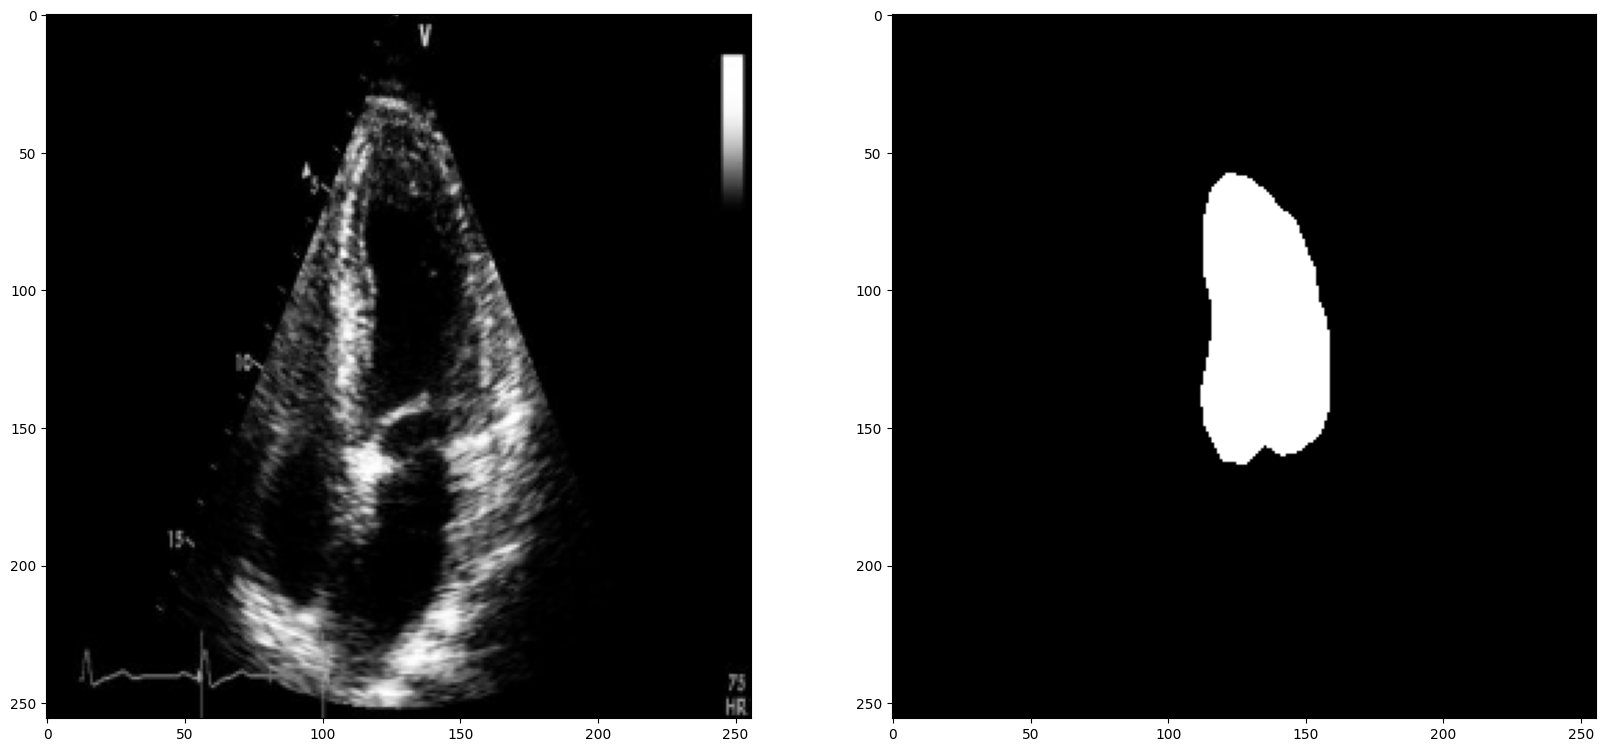

In [ ]:
im, m = next(iter(test_dataset))
fig = plt.figure(figsize=(20,20))

plt.subplot(121)
plt.imshow(ImgForPlot(im));
plt.subplot(122)
# plt.imshow(ImgForPlot(m)[:, :, 0], 'gray');
plt.imshow(m[:, :, 0], 'gray');

In [ ]:
pred = model(im.unsqueeze(0).to(device))[-1]
pred = prepare_output(pred)
pred.shape

(256, 256, 4)

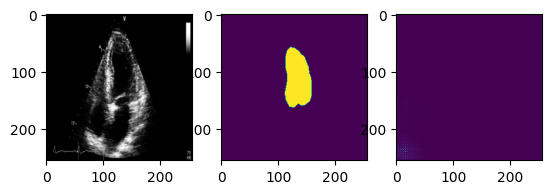

In [ ]:
plt.subplot(131)
plt.imshow(ImgForPlot(im));
# plt.imshow(im.transpose((1, 2, 0)))
plt.subplot(132)
plt.imshow(m[:, :, 0]);
plt.subplot(133)
plt.imshow(pred[:, :, 0]);

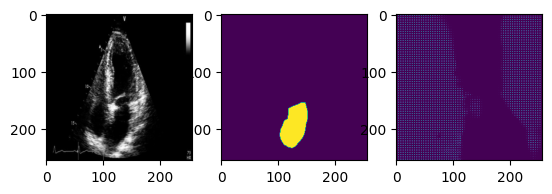

In [ ]:
plt.subplot(131)
plt.imshow(ImgForPlot(im));
plt.subplot(132)
plt.imshow(m[:, :, 1]);
plt.subplot(133)
plt.imshow(pred[:, :, 1]);

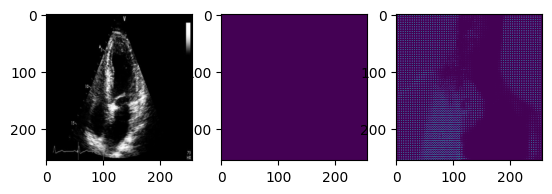

In [ ]:
plt.subplot(131)
plt.imshow(ImgForPlot(im));
plt.subplot(132)
plt.imshow(m[:, :, 2]);
plt.subplot(133)
plt.imshow(pred[:, :, 2]);

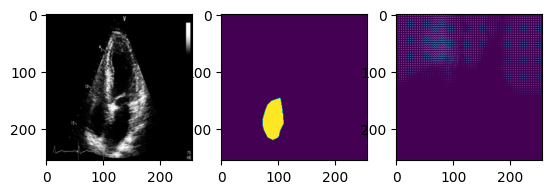

In [ ]:
plt.subplot(131)
plt.imshow(ImgForPlot(im));
plt.subplot(132)
plt.imshow(m[:, :, 3]);
plt.subplot(133)
plt.imshow(pred[:, :, 3]);